# Laboratorio 5: Clasificación de tweets usando minería de texto

## 1. Objetivo

El objetivo es preparar los tweets y construir una solución para distinguir mensajes sobre desastres reales de otros mensajes. El análisis incluye la descripción de los datos, el preprocesamiento, los n-gramas, la comparación de modelos de clasificación, una función para clasificar textos nuevos, el análisis de sentimiento y la evaluación de la negatividad como variable predictora.

In [1]:
from html import unescape
from pathlib import Path
from urllib.parse import unquote
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.svm import LinearSVC
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

SEMILLA = 42
pd.set_option("display.max_colwidth", 120)
plt.style.use("seaborn-v0_8-whitegrid")

## 2. Carga y descripción de los datos

El archivo contiene cinco variables:

- id: identificador del tweet.
- keyword: palabra clave asociada al tweet.
- location: ubicación declarada por la cuenta.
- text: contenido original del tweet.
- target: clase objetivo, donde 1 representa un desastre real y 0 representa otro tipo de mensaje.

In [2]:
rutas_posibles = [Path("data/raw/train.csv"), Path("../data/raw/train.csv")]
RUTA_DATOS = next(ruta for ruta in rutas_posibles if ruta.exists())
datos = pd.read_csv(RUTA_DATOS)

print(f"Dimensiones: {datos.shape[0]:,} filas y {datos.shape[1]} columnas")
display(datos.head())

Dimensiones: 7,613 filas y 5 columnas


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1


In [3]:
perfil_columnas = pd.DataFrame({
    "tipo": datos.dtypes.astype(str),
    "faltantes": datos.isna().sum(),
    "porcentaje_faltante": (datos.isna().mean() * 100).round(2),
    "valores_unicos": datos.nunique(),
})

distribucion_target = datos["target"].value_counts().sort_index().rename_axis("target").to_frame("cantidad")
distribucion_target["porcentaje"] = (distribucion_target["cantidad"] / len(datos) * 100).round(2)

resumen_duplicados = pd.Series({
    "filas_duplicadas_completas": int(datos.duplicated().sum()),
    "registros_con_texto_repetido": int(datos["text"].duplicated(keep=False).sum()),
    "textos_distintos_repetidos": int((datos["text"].value_counts() > 1).sum()),
})

display(perfil_columnas)
display(distribucion_target)
display(resumen_duplicados.to_frame("cantidad"))

,tipo,faltantes,porcentaje_faltante,valores_unicos
id,int64,0,0.00,7613
keyword,object,61,0.80,221
location,object,2533,33.27,3341
text,object,0,0.00,7503
target,int64,0,0.00,2


,cantidad,porcentaje
target,,
0,4342,57.03
1,3271,42.97


,cantidad
filas_duplicadas_completas,0
registros_con_texto_repetido,179
textos_distintos_repetidos,69


### Resultados de la revisión inicial

El conjunto tiene 7,613 registros. La variable location concentra la mayor cantidad de datos faltantes, mientras que text y target están completas. La clase 0 representa cerca del 57 % de los tweets y la clase 1 cerca del 43 %, por lo que existe un desbalance moderado.

No hay filas completamente duplicadas, pero sí hay textos repetidos. Algunos tienen etiquetas diferentes. Estos casos se revisan antes de calcular frecuencias y entrenar el modelo para evitar contar varias veces el mismo mensaje o colocar el mismo texto en entrenamiento y prueba.

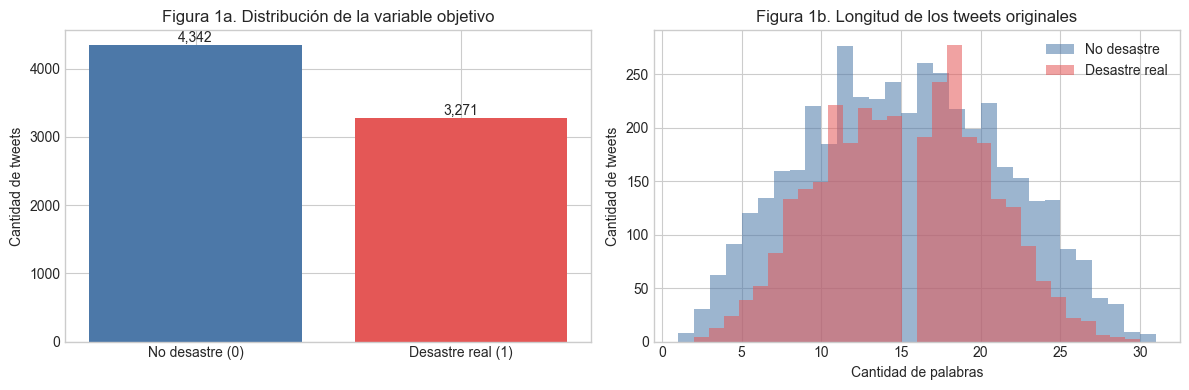

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

colores = ["#4C78A8", "#E45756"]
conteos = datos["target"].value_counts().sort_index()
ax[0].bar(["No desastre (0)", "Desastre real (1)"], conteos.values, color=colores)
ax[0].set_title("Figura 1a. Distribución de la variable objetivo")
ax[0].set_ylabel("Cantidad de tweets")
for indice, valor in enumerate(conteos.values):
    ax[0].text(indice, valor + 50, f"{valor:,}", ha="center")

longitud_palabras = datos["text"].str.split().str.len()
for target, color, etiqueta in [(0, colores[0], "No desastre"), (1, colores[1], "Desastre real")]:
    ax[1].hist(longitud_palabras[datos["target"] == target], bins=30, alpha=0.55, color=color, label=etiqueta)
ax[1].set_title("Figura 1b. Longitud de los tweets originales")
ax[1].set_xlabel("Cantidad de palabras")
ax[1].set_ylabel("Cantidad de tweets")
ax[1].legend()

plt.tight_layout()
plt.show()

In [5]:
datos_keyword = datos.dropna(subset=["keyword"]).copy()
datos_keyword["keyword"] = datos_keyword["keyword"].map(unquote)

top_keywords = (
    datos_keyword.groupby(["target", "keyword"])
    .size()
    .rename("frecuencia")
    .reset_index()
    .sort_values(["target", "frecuencia"], ascending=[True, False])
    .groupby("target", group_keys=False)
    .head(10)
)

presencia_campos = datos.groupby("target").agg(
    porcentaje_con_keyword=("keyword", lambda serie: round(serie.notna().mean() * 100, 2)),
    porcentaje_con_location=("location", lambda serie: round(serie.notna().mean() * 100, 2)),
)

display(presencia_campos)
display(top_keywords.pivot(index="keyword", columns="target", values="frecuencia").fillna(0).astype(int))

,porcentaje_con_keyword,porcentaje_con_location
target,,
0,99.56,66.42
1,98.72,67.14


target,0,1
keyword,,
armageddon,37,0
body bags,40,0
debris,0,37
deluge,36,0
derailment,0,39
evacuated,0,32
explode,35,0
fear,35,0
harm,37,0


### Interpretación exploratoria

La Figura 1 muestra que las dos clases presentan longitudes parecidas y se superponen ampliamente. Por esta razón, la cantidad de palabras no parece suficiente para separar las categorías por sí sola. Las tablas de presencia y frecuencia de keyword muestran diferencias más claras: términos relacionados con daños físicos y emergencias aparecen con mayor fuerza en la clase de desastre real, mientras que varios términos ambiguos también se usan de forma figurada en la clase 0.

La variable location no se usa en los modelos porque tiene muchos datos faltantes y sus valores no siguen un formato uniforme. El contenido de text es la fuente principal de información.

## 3. Limpieza y preprocesamiento

El preprocesamiento aplicado es el siguiente:

1. Convertir entidades HTML y pasar el texto a minúsculas.
2. Eliminar enlaces completos porque suelen identificar una fuente, pero no describen el evento.
3. Eliminar menciones de cuentas para evitar aprender identificadores particulares.
4. Quitar el símbolo de los hashtags, pero conservar la palabra que sigue porque puede describir el desastre.
5. Convertir contracciones negativas como don't en do not antes de quitar los apóstrofes.
6. Eliminar números, excepto 911 por su relación directa con emergencias.
7. Eliminar puntuación, emoticones y otros símbolos.
8. Eliminar palabras vacías en inglés. Se conservan no, not y nor porque pueden cambiar el significado de una frase.
9. Eliminar los términos rt, amp y via, que aparecen por la forma en que se publican o codifican los tweets.

Los textos con etiquetas contradictorias se excluyen del análisis y del modelo. Después se conserva una sola copia de cada texto repetido con etiqueta consistente.

In [6]:
STOPWORDS = set(ENGLISH_STOP_WORDS) - {"no", "not", "nor"}
STOPWORDS.update({"rt", "amp", "via"})

def limpiar_texto(texto):
    texto = unescape(str(texto)).lower()
    texto = re.sub(r"https?://\S+|www\.\S+", " ", texto)
    texto = re.sub(r"@\w+", " ", texto)
    texto = texto.replace("#", "")
    texto = re.sub(r"won['’]t\b", "will not", texto)
    texto = re.sub(r"can['’]t\b", "can not", texto)
    texto = re.sub(r"n['’]t\b", " not", texto)
    texto = re.sub(r"\b\d+\b", lambda coincidencia: " 911 " if coincidencia.group() == "911" else " ", texto)
    tokens = re.findall(r"[a-z]+|911", texto)
    tokens = [token for token in tokens if token not in STOPWORDS and (len(token) > 1 or token == "911")]
    return " ".join(tokens)

etiquetas_por_texto = datos.groupby("text")["target"].nunique()
textos_ambiguos = etiquetas_por_texto[etiquetas_por_texto > 1].index

datos_analisis = (
    datos.loc[~datos["text"].isin(textos_ambiguos)]
    .drop_duplicates(subset="text")
    .copy()
)
datos_analisis["texto_limpio"] = datos_analisis["text"].map(limpiar_texto)

resumen_limpieza = pd.Series({
    "registros_originales": len(datos),
    "textos_con_etiqueta_contradictoria": len(textos_ambiguos),
    "registros_para_analisis": len(datos_analisis),
    "textos_vacios_despues_de_limpieza": int(datos_analisis["texto_limpio"].eq("").sum()),
})

display(resumen_limpieza.to_frame("cantidad"))
display(datos_analisis[["text", "texto_limpio", "target"]].head(8))

,cantidad
registros_originales,7613
textos_con_etiqueta_contradictoria,18
registros_para_analisis,7485
textos_vacios_despues_de_limpieza,5


,text,texto_limpio,target
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,deeds reason earthquake allah forgive,1
1,Forest fire near La Ronge Sask. Canada,forest near la ronge sask canada,1
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,residents asked shelter place notified officers no evacuation shelter place orders expected,1
3,"13,000 people receive #wildfires evacuation orders in California",people receive wildfires evacuation orders california,1
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,just got sent photo ruby alaska smoke wildfires pours school,1
5,#RockyFire Update => California Hwy. 20 closed in both directions due to Lake County fire - #CAfire #wildfires,rockyfire update california hwy closed directions lake county cafire wildfires,1
6,"#flood #disaster Heavy rain causes flash flooding of streets in Manitou, Colorado Springs areas",flood disaster heavy rain causes flash flooding streets manitou colorado springs areas,1
7,I'm on top of the hill and I can see a fire in the woods...,hill woods,1


### Resultado del preprocesamiento

La limpieza reduce ruido sin eliminar las palabras que describen los eventos. Conservar el contenido de los hashtags permite mantener términos como earthquake y wildfires. El tratamiento separado de 911 evita perder una señal de emergencia, mientras que la eliminación de otros números reduce variaciones poco frecuentes.

## 4. Nubes de palabras

Las nubes muestran las palabras más frecuentes de cada clase. El tamaño representa la frecuencia dentro de la categoría y no mide por sí solo la capacidad de clasificación.

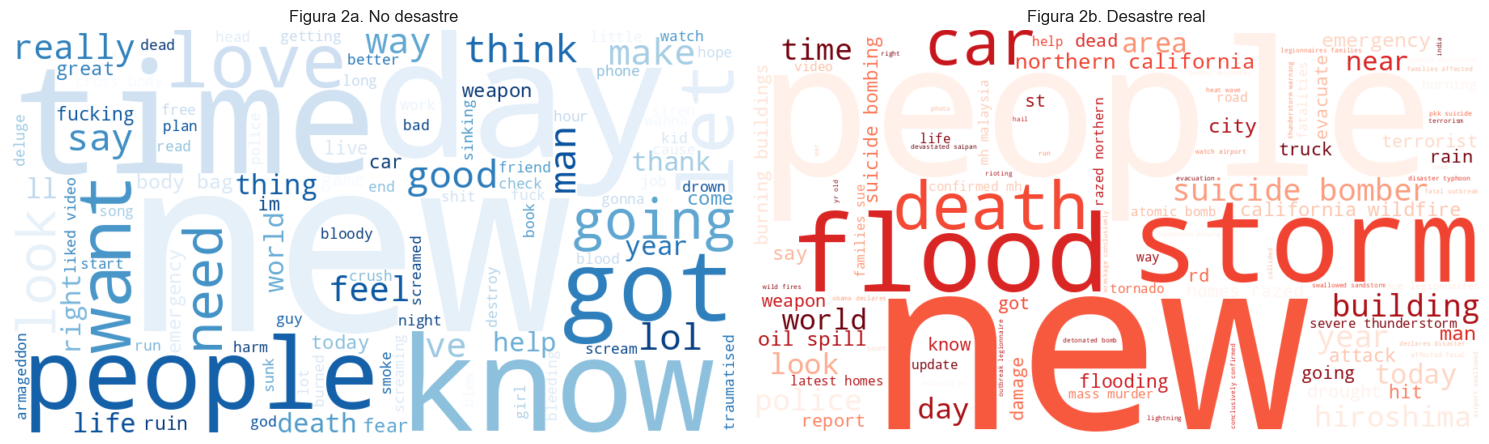

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

for eje, target, titulo, mapa_color in [
    (ax[0], 0, "Figura 2a. No desastre", "Blues"),
    (ax[1], 1, "Figura 2b. Desastre real", "Reds"),
]:
    corpus = " ".join(datos_analisis.loc[datos_analisis["target"] == target, "texto_limpio"])
    nube = WordCloud(
        width=900,
        height=500,
        background_color="white",
        colormap=mapa_color,
        max_words=100,
        random_state=SEMILLA,
    ).generate(corpus)
    eje.imshow(nube, interpolation="bilinear")
    eje.set_title(titulo)
    eje.axis("off")

plt.tight_layout()
plt.show()

La Figura 2 permite observar que los desastres reales concentran términos como fire, flood, storm y disaster. La clase de no desastre contiene más expresiones cotidianas como love, people, time y know. Algunas palabras aparecen en ambas nubes, por lo que la frecuencia visual debe complementarse con contexto.

## 5. Unigramas y bigramas

Un unigrama es una palabra individual y un bigrama es una secuencia de dos palabras. Para cada clase se cuenta la frecuencia total y se calcula la probabilidad relativa dividiendo la frecuencia de cada término entre el total de n-gramas de esa clase.

In [8]:
def calcular_frecuencias_ngramas(textos, n, limite=15):
    vectorizador = CountVectorizer(ngram_range=(n, n), token_pattern=r"(?u)\b\w+\b")
    matriz = vectorizador.fit_transform(textos)
    frecuencias = np.asarray(matriz.sum(axis=0)).ravel()
    tabla = pd.DataFrame({
        "ngrama": vectorizador.get_feature_names_out(),
        "frecuencia": frecuencias,
    })
    tabla["probabilidad"] = tabla["frecuencia"] / tabla["frecuencia"].sum()
    return tabla.nlargest(limite, "frecuencia").reset_index(drop=True)

tablas_ngramas = {}
for n, nombre in [(1, "unigramas"), (2, "bigramas")]:
    for target, clase in [(0, "no_desastre"), (1, "desastre_real")]:
        textos = datos_analisis.loc[datos_analisis["target"] == target, "texto_limpio"]
        tablas_ngramas[(nombre, clase)] = calcular_frecuencias_ngramas(textos, n)

for nombre in ["unigramas", "bigramas"]:
    print(nombre.upper())
    comparacion = pd.concat(
        {
            "No desastre": tablas_ngramas[(nombre, "no_desastre")],
            "Desastre real": tablas_ngramas[(nombre, "desastre_real")],
        },
        axis=1,
    )
    display(comparacion.style.format({
        ("No desastre", "probabilidad"): "{:.4f}",
        ("Desastre real", "probabilidad"): "{:.4f}",
    }))

UNIGRAMAS


BIGRAMAS


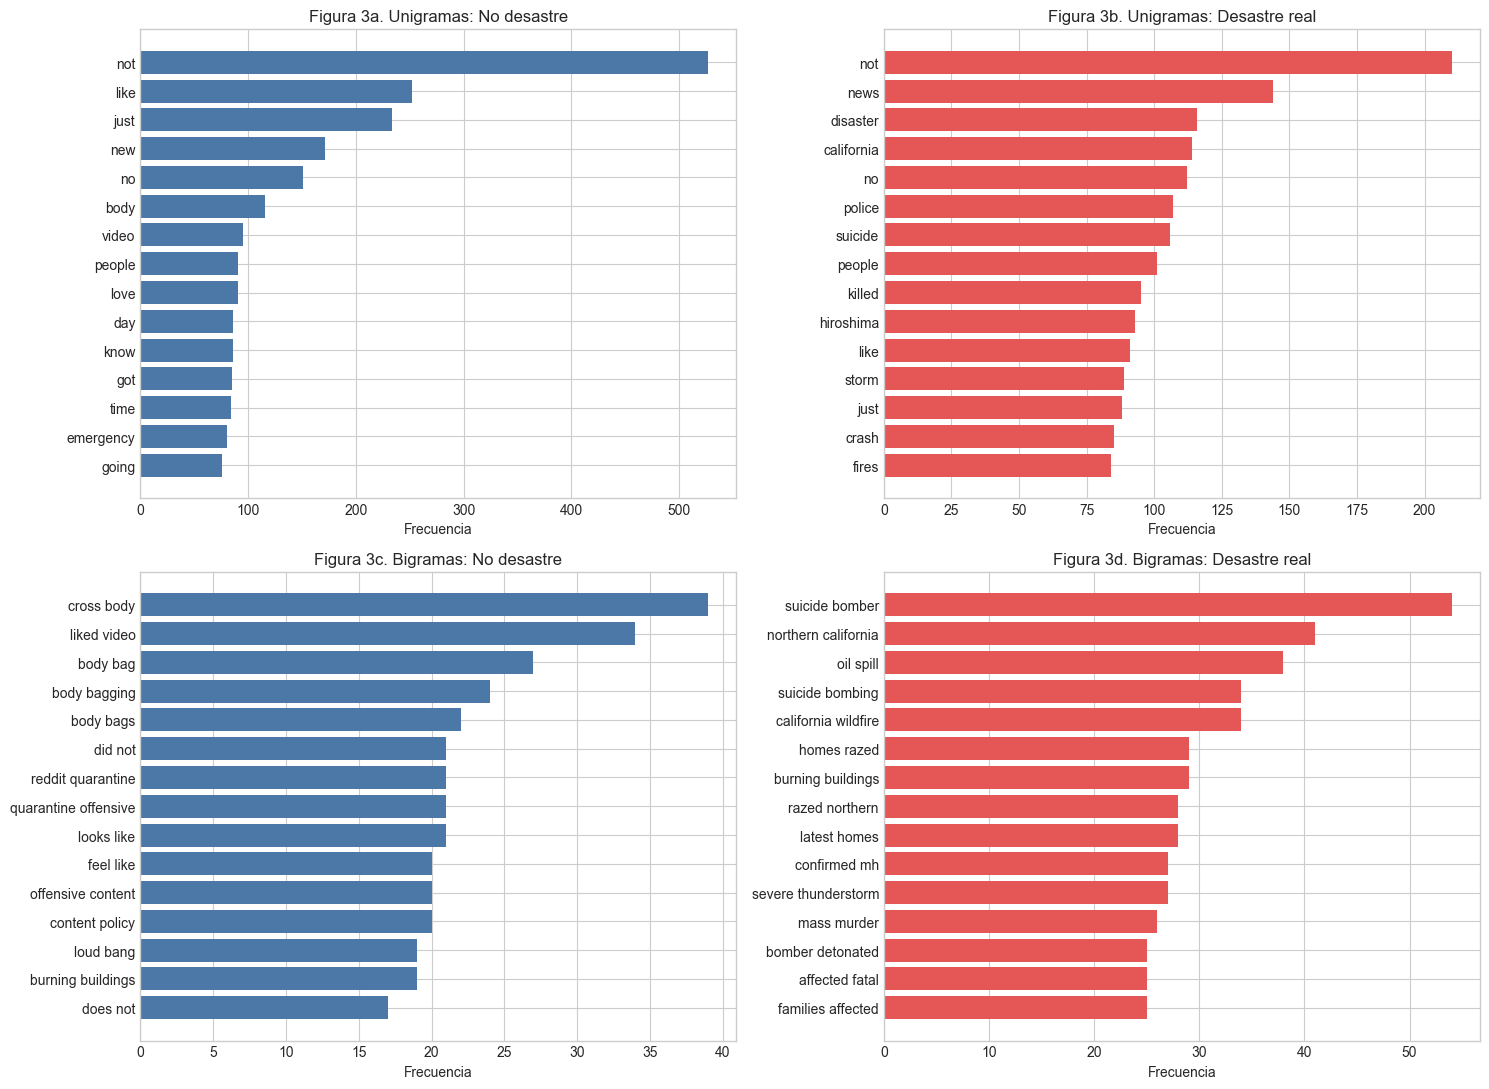

In [9]:
fig, ax = plt.subplots(2, 2, figsize=(15, 11))
etiquetas_figura = [["3a", "3b"], ["3c", "3d"]]

for fila, nombre in enumerate(["unigramas", "bigramas"]):
    for columna, (clase, titulo, color) in enumerate([
        ("no_desastre", "No desastre", "#4C78A8"),
        ("desastre_real", "Desastre real", "#E45756"),
    ]):
        tabla = tablas_ngramas[(nombre, clase)].sort_values("frecuencia")
        ax[fila, columna].barh(tabla["ngrama"], tabla["frecuencia"], color=color)
        ax[fila, columna].set_title(f"Figura {etiquetas_figura[fila][columna]}. {nombre.capitalize()}: {titulo}")
        ax[fila, columna].set_xlabel("Frecuencia")

plt.tight_layout()
plt.show()

### Interpretación de los n-gramas

Las tablas de frecuencia y la Figura 3 muestran que en la clase 1 destacan unigramas como disaster, police, killed y storm. En la clase 0 aparecen términos más cotidianos como like, just, new y love. Palabras como people, like y not están presentes en ambas categorías, por lo que una palabra aislada no siempre permite distinguir el sentido literal del figurado.

Los bigramas agregan contexto local. En los desastres reales aparecen combinaciones como suicide bomber, northern california y oil spill. El bigrama burning buildings aparece en ambas clases, lo que confirma que incluso una frase relacionada con desastres puede utilizarse de forma literal o figurada. Se incluyen unigramas y bigramas en los modelos, pero no trigramas porque son menos frecuentes y pueden aumentar demasiado la cantidad de variables.

## 6. Comparación de modelos de clasificación

El contexto se representa mediante TF-IDF con unigramas y bigramas. Los unigramas capturan palabras informativas y los bigramas conservan relaciones cercanas como oil spill o suicide bomber. Se exige una frecuencia mínima de dos documentos para reducir términos demasiado raros y se aplica frecuencia sublineal para limitar el peso de las repeticiones.

Se comparan tres algoritmos:

- Regresión logística: C=1.0, class_weight=balanced y max_iter=1000.
- Máquinas de soporte vectorial lineal: C=1.0 y class_weight=balanced.
- Naive Bayes complementario: alpha=0.5.

La comparación usa validación cruzada estratificada de cinco particiones sobre el 80 % destinado a entrenamiento. El modelo con mayor F1 promedio para la clase de desastre real se selecciona antes de evaluar el 20 % de prueba. La clase 1 se prioriza porque omitir un desastre real representa el error más importante del problema.

In [10]:
datos_modelo = datos_analisis.loc[datos_analisis["texto_limpio"].ne("")].copy()
X = datos_modelo["text"]
y = datos_modelo["target"]

X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEMILLA,
    stratify=y,
)

def crear_vectorizador():
    return TfidfVectorizer(
        preprocessor=limpiar_texto,
        lowercase=False,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
    )

modelos = {
    "Regresión logística": Pipeline([
        ("tfidf", crear_vectorizador()),
        ("clasificador", LogisticRegression(
            C=1.0,
            class_weight="balanced",
            max_iter=1000,
            random_state=SEMILLA,
        )),
    ]),
    "SVM lineal": Pipeline([
        ("tfidf", crear_vectorizador()),
        ("clasificador", LinearSVC(
            C=1.0,
            class_weight="balanced",
            random_state=SEMILLA,
        )),
    ]),
    "Naive Bayes complementario": Pipeline([
        ("tfidf", crear_vectorizador()),
        ("clasificador", ComplementNB(alpha=0.5)),
    ]),
}

print(f"Entrenamiento: {len(X_entrenamiento):,} tweets")
print(f"Prueba: {len(X_prueba):,} tweets")

Entrenamiento: 5,984 tweets
Prueba: 1,496 tweets


In [11]:
validacion = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
metricas_validacion = {
    "exactitud": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

resultados_validacion = []
for nombre, modelo in modelos.items():
    resultado = cross_validate(
        modelo,
        X_entrenamiento,
        y_entrenamiento,
        cv=validacion,
        scoring=metricas_validacion,
        n_jobs=1,
    )
    resultados_validacion.append({
        "modelo": nombre,
        "exactitud_promedio": resultado["test_exactitud"].mean(),
        "precision_promedio": resultado["test_precision"].mean(),
        "recall_promedio": resultado["test_recall"].mean(),
        "f1_promedio": resultado["test_f1"].mean(),
        "f1_desviacion": resultado["test_f1"].std(),
    })

tabla_validacion = (
    pd.DataFrame(resultados_validacion)
    .sort_values("f1_promedio", ascending=False)
    .reset_index(drop=True)
)
nombre_mejor_modelo = tabla_validacion.loc[0, "modelo"]

display(tabla_validacion.style.format({
    "exactitud_promedio": "{:.3f}",
    "precision_promedio": "{:.3f}",
    "recall_promedio": "{:.3f}",
    "f1_promedio": "{:.3f}",
    "f1_desviacion": "{:.3f}",
}))
print(f"Modelo seleccionado: {nombre_mejor_modelo}")

,modelo,exactitud_promedio,precision_promedio,recall_promedio,f1_promedio,f1_desviacion
0,Regresión logística,0.796,0.770,0.744,0.757,0.015
1,Naive Bayes complementario,0.796,0.786,0.718,0.750,0.014
2,SVM lineal,0.771,0.730,0.734,0.732,0.018


Modelo seleccionado: Regresión logística


### Evaluación en el conjunto de prueba

Después de seleccionar el algoritmo mediante validación cruzada, se entrena una copia con todo el conjunto de entrenamiento. La línea base siempre predice la clase mayoritaria y permite verificar si el modelo aprende información adicional.

,exactitud,precision_clase_1,recall_clase_1,f1_clase_1
Línea base,0.574,0.000,0.000,0.000
Regresión logística,0.781,0.761,0.708,0.733


,precision,recall,f1-score,support
No desastre,0.794,0.835,0.814,859.000
Desastre real,0.761,0.708,0.733,637.000
accuracy,0.781,0.781,0.781,0.781
macro avg,0.777,0.771,0.774,1496.000
weighted avg,0.780,0.781,0.780,1496.000


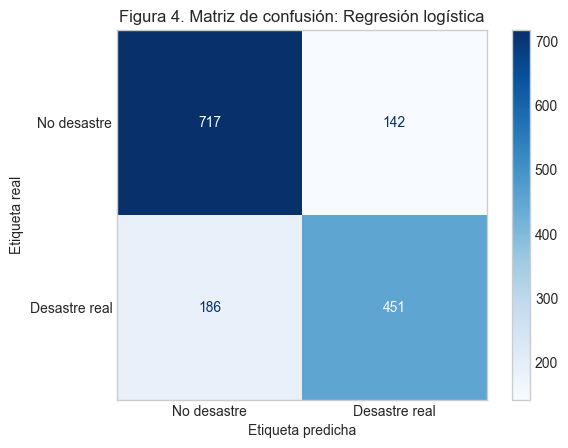

In [12]:
def obtener_metricas(y_real, y_predicho):
    return {
        "exactitud": accuracy_score(y_real, y_predicho),
        "precision_clase_1": precision_score(y_real, y_predicho, zero_division=0),
        "recall_clase_1": recall_score(y_real, y_predicho, zero_division=0),
        "f1_clase_1": f1_score(y_real, y_predicho, zero_division=0),
    }

mejor_modelo = clone(modelos[nombre_mejor_modelo])
mejor_modelo.fit(X_entrenamiento, y_entrenamiento)
prediccion_mejor_modelo = mejor_modelo.predict(X_prueba)

modelo_base = DummyClassifier(strategy="most_frequent")
modelo_base.fit(np.zeros((len(y_entrenamiento), 1)), y_entrenamiento)
prediccion_base = modelo_base.predict(np.zeros((len(y_prueba), 1)))

metricas_prueba = pd.DataFrame({
    "Línea base": obtener_metricas(y_prueba, prediccion_base),
    nombre_mejor_modelo: obtener_metricas(y_prueba, prediccion_mejor_modelo),
}).T

reporte_clases = pd.DataFrame(
    classification_report(
        y_prueba,
        prediccion_mejor_modelo,
        target_names=["No desastre", "Desastre real"],
        output_dict=True,
        zero_division=0,
    )
).T

display(metricas_prueba.style.format("{:.3f}"))
display(reporte_clases.style.format("{:.3f}"))

ConfusionMatrixDisplay.from_predictions(
    y_prueba,
    prediccion_mejor_modelo,
    display_labels=["No desastre", "Desastre real"],
    cmap="Blues",
)
plt.title(f"Figura 4. Matriz de confusión: {nombre_mejor_modelo}")
plt.xlabel("Etiqueta predicha")
plt.ylabel("Etiqueta real")
plt.grid(False)
plt.show()

### Resultado de la selección

La tabla de validación muestra que la regresión logística obtiene el mayor F1 promedio: 0.757, frente a 0.750 de Naive Bayes complementario y 0.732 de SVM lineal. Por esta razón se selecciona la regresión logística. En el conjunto de prueba alcanza 0.781 de exactitud y 0.733 de F1 para la clase de desastre real. La precisión de esa clase es 0.761 y el recall es 0.708. La línea base obtiene 0.574 de exactitud y no detecta ningún desastre real. La Figura 4 presenta los aciertos y errores por categoría.

## 7. Función de clasificación

La función recibe un tweet sin preprocesar. El pipeline aplica exactamente la misma limpieza y transformación TF-IDF utilizadas durante el entrenamiento y devuelve la categoría predicha.

In [13]:
ETIQUETAS_DESASTRE = {0: "No desastre", 1: "Desastre real"}

def clasificar_tweet(tweet):
    if not isinstance(tweet, str) or not tweet.strip():
        raise ValueError("El tweet debe ser una cadena de texto no vacía.")
    prediccion = int(mejor_modelo.predict([tweet])[0])
    return ETIQUETAS_DESASTRE[prediccion]

ejemplos_clasificacion = pd.DataFrame({
    "tweet": [
        "A wildfire is spreading near the town and residents are being evacuated",
        "That concert was fire, I had the best night ever",
        "Emergency crews respond after a train crash downtown",
    ]
})
ejemplos_clasificacion["clasificacion"] = ejemplos_clasificacion["tweet"].map(clasificar_tweet)
display(ejemplos_clasificacion)

,tweet,clasificacion
0,A wildfire is spreading near the town and residents are being evacuated,Desastre real
1,"That concert was fire, I had the best night ever",No desastre
2,Emergency crews respond after a train crash downtown,Desastre real


La función valida que el texto no esté vacío y conserva todo el preprocesamiento dentro del pipeline. Esto evita diferencias entre el tratamiento de los datos de entrenamiento y el de los tweets nuevos.

## 8. Análisis de sentimiento

El sentimiento se calcula con VADER, un método basado en un léxico y reglas diseñadas para textos de redes sociales. El método devuelve proporciones positivas, negativas y neutras, además de un valor compuesto entre -1 y 1. Se usa el criterio recomendado por VADER:

- Positivo: valor compuesto mayor o igual que 0.05.
- Negativo: valor compuesto menor o igual que -0.05.
- Neutro: valor compuesto entre -0.05 y 0.05.

El análisis se aplica al texto original. Esto conserva mayúsculas, signos de puntuación, emoticones y expresiones de intensidad que aportan información al método. El texto limpio continúa utilizándose para TF-IDF, pero no para el cálculo del sentimiento.

In [14]:
analizador_sentimiento = SentimentIntensityAnalyzer()

def analizar_sentimiento(texto):
    puntajes = analizador_sentimiento.polarity_scores(str(texto))
    compuesto = puntajes["compound"]
    if compuesto >= 0.05:
        categoria = "Positivo"
    elif compuesto <= -0.05:
        categoria = "Negativo"
    else:
        categoria = "Neutro"
    return pd.Series({
        "sentimiento_positivo": puntajes["pos"],
        "negatividad": puntajes["neg"],
        "sentimiento_neutro": puntajes["neu"],
        "sentimiento_compuesto": compuesto,
        "clasificacion_sentimiento": categoria,
    })

puntajes_sentimiento = datos_modelo["text"].apply(analizar_sentimiento)
datos_sentimiento = pd.concat([datos_modelo, puntajes_sentimiento], axis=1)
datos_sentimiento["categoria_desastre"] = datos_sentimiento["target"].map(ETIQUETAS_DESASTRE)

distribucion_sentimiento = pd.crosstab(
    datos_sentimiento["categoria_desastre"],
    datos_sentimiento["clasificacion_sentimiento"],
)
porcentaje_sentimiento = distribucion_sentimiento.div(distribucion_sentimiento.sum(axis=1), axis=0) * 100

display(distribucion_sentimiento)
display(porcentaje_sentimiento.style.format("{:.2f} %"))

clasificacion_sentimiento,Negativo,Neutro,Positivo
categoria_desastre,,,
Desastre real,1843,823,521
No desastre,1834,1049,1410


clasificacion_sentimiento,Negativo,Neutro,Positivo
categoria_desastre,,,
Desastre real,57.83 %,25.82 %,16.35 %
No desastre,42.72 %,24.44 %,32.84 %


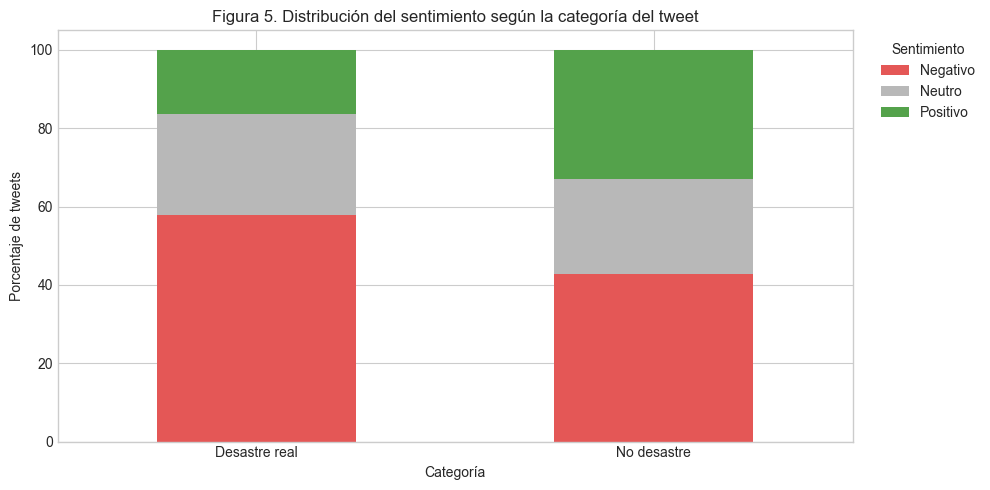

In [15]:
orden_sentimiento = ["Negativo", "Neutro", "Positivo"]
colores_sentimiento = ["#E45756", "#B8B8B8", "#54A24B"]

ax = porcentaje_sentimiento.reindex(columns=orden_sentimiento).plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    color=colores_sentimiento,
)
ax.set_title("Figura 5. Distribución del sentimiento según la categoría del tweet")
ax.set_xlabel("Categoría")
ax.set_ylabel("Porcentaje de tweets")
ax.legend(title="Sentimiento", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

La Figura 5 muestra una mayor proporción de sentimiento negativo en los desastres reales y una mayor proporción positiva en la clase de no desastre.

### Tweets con sentimiento más extremo

Los tweets se ordenan por el valor compuesto. En caso de empate, la proporción negativa o positiva permite priorizar los textos con mayor intensidad en la dirección correspondiente. La categoría indica si el tweet fue etiquetado como desastre real o no desastre.

In [16]:
columnas_extremos = [
    "id",
    "categoria_desastre",
    "sentimiento_compuesto",
    "negatividad",
    "sentimiento_positivo",
    "text",
]

tweets_mas_negativos = (
    datos_sentimiento
    .sort_values(["sentimiento_compuesto", "negatividad"], ascending=[True, False])
    .head(10)[columnas_extremos]
    .reset_index(drop=True)
)
tweets_mas_positivos = (
    datos_sentimiento
    .sort_values(["sentimiento_compuesto", "sentimiento_positivo"], ascending=[False, False])
    .head(10)[columnas_extremos]
    .reset_index(drop=True)
)

print("10 tweets más negativos")
display(tweets_mas_negativos.style.format({
    "sentimiento_compuesto": "{:.4f}",
    "negatividad": "{:.3f}",
    "sentimiento_positivo": "{:.3f}",
}))

print("10 tweets más positivos")
display(tweets_mas_positivos.style.format({
    "sentimiento_compuesto": "{:.4f}",
    "negatividad": "{:.3f}",
    "sentimiento_positivo": "{:.3f}",
}))

10 tweets más negativos


,id,categoria_desastre,sentimiento_compuesto,negatividad,sentimiento_positivo,text
0,10689,No desastre,-0.9883,1.000,0.000,wreck? wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck?
1,9172,Desastre real,-0.9686,0.528,0.000,@Abu_Baraa1 Suicide bomber targets Saudi mosque at least 13 dead - Suicide bomber targets Saudi mosque at least 13 dead This is ridiculous
2,9166,Desastre real,-0.9623,0.509,0.061,Suicide bomber kills 15 in Saudi security site mosque - A suicide bomber killed at least 15 people in an attack on... http://t.co/FY0r9o7Xsl
3,9137,Desastre real,-0.9595,0.548,0.000,? 19th Day Since 17-Jul-2015 -- Nigeria: Suicide Bomb Attacks Killed 64 People; Blamed: Boko Haram [L.A. Times/AP] | http://t.co/O2cdKpSDfp
4,9782,No desastre,-0.9556,0.453,0.000,@dramaa_llama but otherwise i will stay trapped as the worst lilourry stan ever AND without zarry what am I left with? NARRY. NO THANKS.
5,9159,Desastre real,-0.9552,0.541,0.000,17 killed in SÛªArabia mosque suicide bombing A suicide bomber attacked a mosque in Aseer south-western Saudi... http://t.co/pMTQhiVsXX
6,4213,No desastre,-0.9549,0.507,0.000,at the lake *sees a dead fish* me: poor little guy i wonder what happened ashley: idk maybe it drowned wtf ????????
7,682,Desastre real,-0.9538,0.520,0.000,illegal alien released by Obama/DHS 4 times Charged With Rape & Murder of Santa Maria CA Woman Had Prior Offenses http://t.co/MqP4hF9GpO
8,2225,Desastre real,-0.9524,0.566,0.096,Bomb Crash Loot Riot Emergency Pipe Bomb Nuclear Chemical Spill Gas Ricin Leak Violence Drugs Cartel Cocaine Marijuana Heroine Kidnap Bust
9,9940,Desastre real,-0.9493,0.481,0.060,@cspan #Prez. Mr. President you are the biggest terrorist and trouble maker in the world. You create terrorist you sponsor terrorist.


10 tweets más positivos


,id,categoria_desastre,sentimiento_compuesto,negatividad,sentimiento_positivo,text
0,10028,No desastre,0.9730,0.000,0.568,Check out 'Want Twister Tickets AND A VIP EXPERIENCE To See SHANIA? CLICK HERE:' at http://t.co/3GEROQ49o1 I would Love Love Love!! To win
1,9345,No desastre,0.9564,0.047,0.524,@thoutaylorbrown I feel like accidents are just drawn to you but I'm happy you've survived all of them. Hope you're okay!!!
2,8989,Desastre real,0.9471,0.000,0.477,TodayÛªs storm will pass; let tomorrowÛªs light greet you with a kiss. Bask in this loving warmth; let your soul return to bliss.
3,8136,No desastre,0.9428,0.000,0.405,@Zak_Bagans pets r like part of the family. I love animals.??? The last 2 pets I had I rescued! Breaks my heart when animals are mistreated????
4,4541,No desastre,0.9423,0.081,0.545,@batfanuk we enjoyed the show today. Great fun. The emergency non evacuation was interesting. Have a great run.
5,9710,No desastre,0.9394,0.000,0.571,Maaaaan I love Love Without Tragedy by @rihanna I wish she made the whole song
6,8994,No desastre,0.9376,0.000,0.607,Free Ebay Sniping RT? http://t.co/B231Ul1O1K Lumbar Extender Back Stretcher Excellent Condition!! ?Please Favorite & Share
7,1453,No desastre,0.9345,0.057,0.522,I'm not a Drake fan but I enjoy seeing him body-bagging people. Great marketing lol.
8,9386,No desastre,0.9344,0.000,0.503,@duchovbutt @Starbuck_Scully @MadMakNY @davidduchovny yeah we survived 9 seasons and 2 movies. Let's hope for the good. There's hope ??????
9,8759,No desastre,0.9300,0.000,0.873,Super sweet and beautiful :) https://t.co/TUi9uwBvVp


Entre los 10 tweets más negativos hay siete desastres reales y tres textos de la clase 0. Entre los 10 más positivos hay un desastre real y nueve textos de la clase 0. Estos resultados son coherentes con una mayor presencia de lenguaje negativo en los desastres reales, aunque también muestran casos extremos en ambas categorías.

## 9. Comparación de negatividad entre categorías

La variable negatividad corresponde a la proporción negativa calculada por VADER y toma valores entre 0 y 1. Un valor alto indica mayor presencia de contenido negativo. Se comparan la media, la mediana y el porcentaje de tweets clasificados como negativos en cada categoría.

,cantidad,negatividad_media,negatividad_mediana,compuesto_medio,porcentaje_negativos
categoria_desastre,,,,,
Desastre real,3187,0.173,0.157,-0.267,57.83 %
No desastre,4293,0.131,0.096,-0.052,42.72 %


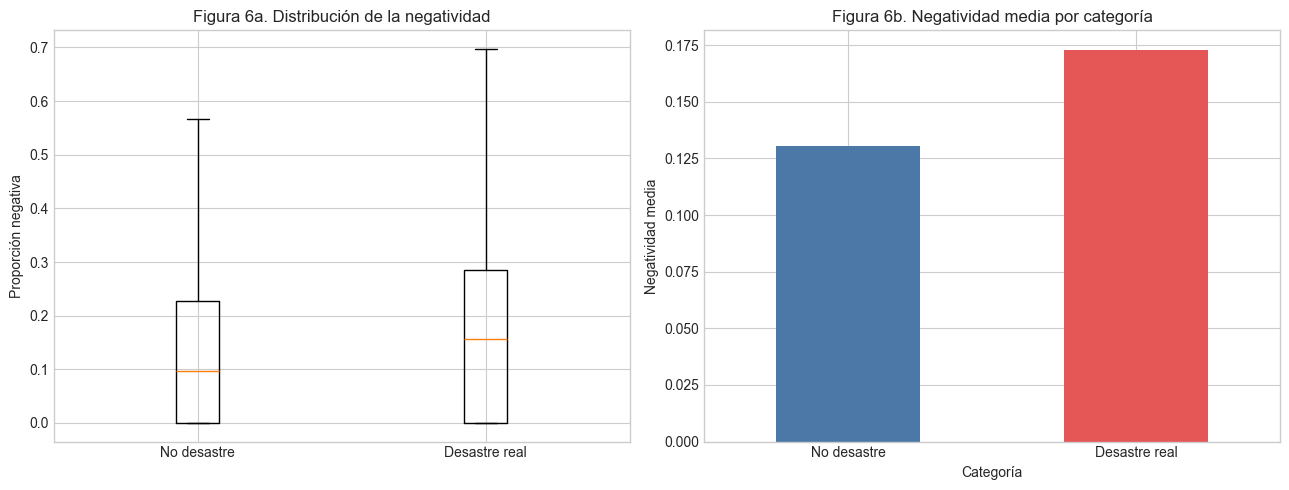

In [17]:
resumen_negatividad = datos_sentimiento.groupby("categoria_desastre").agg(
    cantidad=("id", "size"),
    negatividad_media=("negatividad", "mean"),
    negatividad_mediana=("negatividad", "median"),
    compuesto_medio=("sentimiento_compuesto", "mean"),
    porcentaje_negativos=(
        "clasificacion_sentimiento",
        lambda serie: (serie == "Negativo").mean() * 100,
    ),
)

display(resumen_negatividad.style.format({
    "negatividad_media": "{:.3f}",
    "negatividad_mediana": "{:.3f}",
    "compuesto_medio": "{:.3f}",
    "porcentaje_negativos": "{:.2f} %",
}))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

series_negatividad = [
    datos_sentimiento.loc[datos_sentimiento["target"] == target, "negatividad"]
    for target in [0, 1]
]
ax[0].boxplot(series_negatividad, tick_labels=["No desastre", "Desastre real"], showfliers=False)
ax[0].set_title("Figura 6a. Distribución de la negatividad")
ax[0].set_ylabel("Proporción negativa")

resumen_negatividad.reindex(["No desastre", "Desastre real"])["negatividad_media"].plot(
    kind="bar",
    color=["#4C78A8", "#E45756"],
    ax=ax[1],
)
ax[1].set_title("Figura 6b. Negatividad media por categoría")
ax[1].set_xlabel("Categoría")
ax[1].set_ylabel("Negatividad media")
ax[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### Interpretación de la negatividad

La tabla de resumen y la Figura 6 muestran que los tweets sobre desastres reales son más negativos en este conjunto de datos. Su negatividad media es 0.173 y su mediana es 0.157, frente a 0.131 y 0.096 en la clase de no desastre. Además, VADER clasifica como negativos al 57.83 % de los desastres reales y al 42.72 % de los demás tweets. El valor compuesto medio también es más bajo en los desastres reales: -0.267 frente a -0.052. La diferencia representa una asociación en este conjunto y no una relación causal.

## 10. Modelo con la variable de negatividad

La negatividad se agrega como una variable numérica al conjunto de características TF-IDF. Se conserva el mismo algoritmo seleccionado, la misma división de entrenamiento y prueba y los mismos parámetros. De esta manera, la diferencia en las métricas se atribuye únicamente a la nueva variable.

La extracción de negatividad forma parte del pipeline, por lo que el modelo continúa recibiendo texto sin procesar.

In [18]:
def extraer_negatividad(textos):
    return np.asarray([
        [analizador_sentimiento.polarity_scores(str(texto))["neg"]]
        for texto in textos
    ])

caracteristicas_con_negatividad = FeatureUnion([
    ("tfidf", crear_vectorizador()),
    ("negatividad", FunctionTransformer(extraer_negatividad, validate=False)),
])

modelo_con_negatividad = Pipeline([
    ("caracteristicas", caracteristicas_con_negatividad),
    ("clasificador", clone(modelos[nombre_mejor_modelo].named_steps["clasificador"])),
])

modelo_con_negatividad.fit(X_entrenamiento, y_entrenamiento)
prediccion_con_negatividad = modelo_con_negatividad.predict(X_prueba)

comparacion_negatividad = pd.DataFrame({
    "Solo TF-IDF": obtener_metricas(y_prueba, prediccion_mejor_modelo),
    "TF-IDF y negatividad": obtener_metricas(y_prueba, prediccion_con_negatividad),
}).T
comparacion_negatividad.loc["Cambio", :] = (
    comparacion_negatividad.loc["TF-IDF y negatividad"]
    - comparacion_negatividad.loc["Solo TF-IDF"]
)

f1_solo_texto = comparacion_negatividad.loc["Solo TF-IDF", "f1_clase_1"]
f1_con_negatividad = comparacion_negatividad.loc["TF-IDF y negatividad", "f1_clase_1"]

if f1_con_negatividad > f1_solo_texto:
    mejor_modelo = modelo_con_negatividad
    configuracion_final = "TF-IDF y negatividad"
else:
    configuracion_final = "Solo TF-IDF"

display(comparacion_negatividad.style.format("{:.3f}"))
print(f"Configuración final: {configuracion_final}")

,exactitud,precision_clase_1,recall_clase_1,f1_clase_1
Solo TF-IDF,0.781,0.761,0.708,0.733
TF-IDF y negatividad,0.772,0.750,0.697,0.723
Cambio,-0.009,-0.011,-0.011,-0.011


Configuración final: Solo TF-IDF


In [19]:
ejemplos_clasificacion["clasificacion_final"] = ejemplos_clasificacion["tweet"].map(clasificar_tweet)
display(ejemplos_clasificacion[["tweet", "clasificacion_final"]])

,tweet,clasificacion_final
0,A wildfire is spreading near the town and residents are being evacuated,Desastre real
1,"That concert was fire, I had the best night ever",No desastre
2,Emergency crews respond after a train crash downtown,Desastre real


### Efecto de la negatividad

La tabla comparativa muestra que la variable de negatividad no mejora el modelo. La exactitud disminuye de 0.781 a 0.772 y el F1 de la clase de desastre real baja de 0.733 a 0.723. La precisión y el recall también disminuyen en 0.011. Por lo tanto, la configuración final conserva únicamente TF-IDF. Una explicación posible es que el contenido negativo ya está representado por las palabras y bigramas, por lo que la variable adicional aporta información redundante.

## 11. Conclusiones

- La regresión logística obtuvo el mejor F1 promedio en validación cruzada y alcanzó 0.781 de exactitud y 0.733 de F1 para desastres reales en el conjunto de prueba.
- Los bigramas ayudan a representar contexto cercano sin generar la dispersión adicional de los trigramas.
- Los tweets sobre desastres reales presentan mayor negatividad media y una proporción más alta de sentimiento negativo.
- La negatividad no mejora la clasificación: reduce la exactitud en 0.009 y el F1 en 0.011. El modelo final utiliza únicamente TF-IDF.
- La función de clasificación recibe texto sin procesar porque la limpieza y la transformación TF-IDF están integradas en el pipeline.

## 12. Referencias

- Hutto, C. J. y Gilbert, E. (2014). VADER: A Parsimonious Rule-based Model for Sentiment Analysis of Social Media Text. Proceedings of the International AAAI Conference on Web and Social Media. https://ojs.aaai.org/index.php/ICWSM/article/view/14550
- Scikit-learn. TfidfVectorizer. https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html
- Scikit-learn. Model evaluation. https://scikit-learn.org/stable/modules/model_evaluation.html
- Kaggle. Natural Language Processing with Disaster Tweets. https://www.kaggle.com/competitions/nlp-getting-started